# 16 — Cloude–Pottier H/A/α (Memory-Safe Full-Pol)

Compute **Cloude–Pottier entropy (H), anisotropy (A), and mean alpha (α)** from the same LSAR full-polarimetric subset used by the preceding modules.

### Important implementation change

The original version passed the complete scene `(5597 × 5048)` into `eigen_analysis()`.  
Although the polarimetric mathematics is correct, `np.linalg.eigh()` then attempts a scene-wide eigendecomposition of millions of 3×3 matrices and can require several GB of temporary memory.

This revised module performs the **same scientific calculation tile-by-tile**. The eigendecomposition is still performed independently for every pixel; only the amount of data held in memory at one time changes.

**Default tile:** 512 × 512 pixels.

This approach is intended to be robust for large NISAR full-pol scenes without changing the Cloude–Pottier formulation.


Exact v8 subset: {'r0': 7056, 'r1': 12653, 'c0': 6459, 'c1': 11507}
Raster size: 5597 × 5048
Tile size:   512 × 512
Processed tile 110/110 (100.0%)
Cloude–Pottier processing complete.

Results
-------
H median: 0.6522417664527893
A median: 0.5183325409889221
alpha median (deg): 53.92898178100586


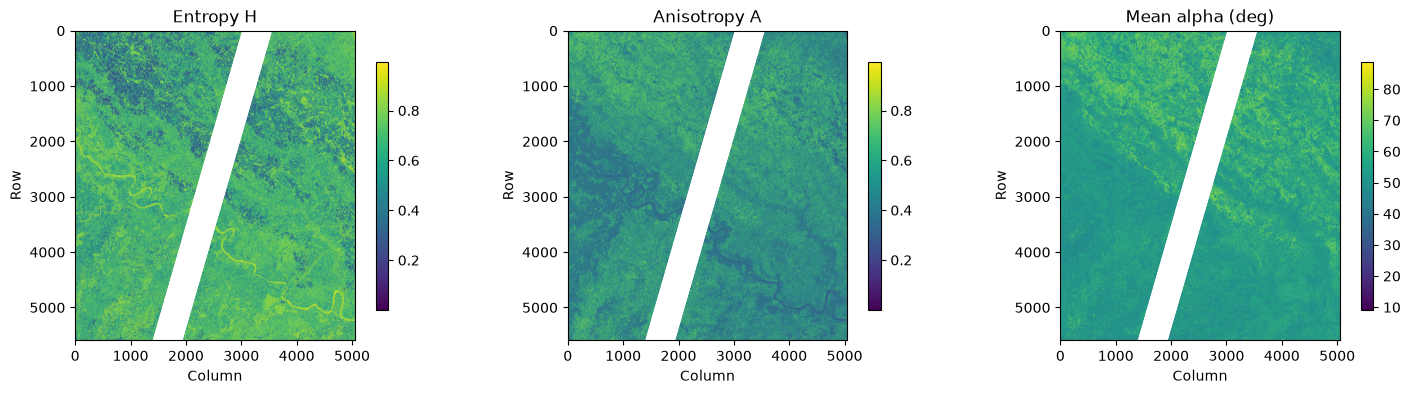

In [1]:
import gc
import numpy as np
import matplotlib.pyplot as plt

from nisar_utils.config import load_config
from nisar_utils.polarimetric_io import (
    load_detected_mode,
    load_branch_terms,
    FULL_POL_TERMS,
)
from nisar_utils.polarimetry import (
    covariance_hermitian_from_terms,
    nisar_c3_to_standard_c3,
    standard_c3_to_t3,
    eigen_analysis,
    cloude_pottier_mean_alpha,
)

# ---------------------------------------------------------------------
# User control
# ---------------------------------------------------------------------
TILE_SIZE = 512          # Reduce to 256 if RAM is still limited.
STORE_FLOAT32 = True     # H, A and alpha are stored as float32 to save RAM.
SHOW_RESULTS = True

cfg = load_config()
mode = load_detected_mode(cfg)

if mode["polarimetric_mode"] != "LSAR_FULL_POL":
    print("SKIPPED:", mode["polarimetric_mode"])

else:
    # ---------------------------------------------------------------
    # Load exactly the same full-pol terms/subset as the original
    # Module 16.
    # ---------------------------------------------------------------
    data, sp, guard, mode = load_branch_terms(cfg, FULL_POL_TERMS)

    # ---------------------------------------------------------------
    # Find the raster shape from the loaded term arrays.
    # The branch loader is expected to return a dictionary of raster
    # terms. This helper also handles nested dictionaries.
    # ---------------------------------------------------------------
    def _find_raster_shape(obj):
        if isinstance(obj, dict):
            for value in obj.values():
                shape = _find_raster_shape(value)
                if shape is not None:
                    return shape
        elif isinstance(obj, (list, tuple)):
            for value in obj:
                shape = _find_raster_shape(value)
                if shape is not None:
                    return shape
        else:
            try:
                a = np.asarray(obj)
                if a.ndim >= 2:
                    return a.shape[:2]
            except Exception:
                pass
        return None

    raster_shape = _find_raster_shape(data)
    if raster_shape is None:
        raise RuntimeError("Could not determine raster shape from FULL_POL_TERMS.")

    rows, cols = raster_shape
    print(f"Exact v8 subset: {sp}")
    print(f"Raster size: {rows} × {cols}")
    print(f"Tile size:   {TILE_SIZE} × {TILE_SIZE}")

    # ---------------------------------------------------------------
    # Slice only raster-sized arrays. Scalar metadata is retained.
    # ---------------------------------------------------------------
    def _slice_raster_terms(obj, r0, r1, c0, c1):
        if isinstance(obj, dict):
            return {
                key: _slice_raster_terms(value, r0, r1, c0, c1)
                for key, value in obj.items()
            }
        elif isinstance(obj, list):
            return [_slice_raster_terms(value, r0, r1, c0, c1) for value in obj]
        elif isinstance(obj, tuple):
            return tuple(
                _slice_raster_terms(value, r0, r1, c0, c1)
                for value in obj
            )
        else:
            try:
                a = np.asarray(obj)
                if a.ndim >= 2 and a.shape[:2] == (rows, cols):
                    return a[r0:r1, c0:c1, ...]
            except Exception:
                pass
            return obj

    # ---------------------------------------------------------------
    # Output products.
    # Each is one scalar per pixel, so float32 is sufficient for
    # display/product generation and greatly reduces memory use.
    # ---------------------------------------------------------------
    out_dtype = np.float32 if STORE_FLOAT32 else np.float64

    H = np.full((rows, cols), np.nan, dtype=out_dtype)
    A = np.full((rows, cols), np.nan, dtype=out_dtype)
    alpha = np.full((rows, cols), np.nan, dtype=out_dtype)

    ntiles_r = (rows + TILE_SIZE - 1) // TILE_SIZE
    ntiles_c = (cols + TILE_SIZE - 1) // TILE_SIZE
    total_tiles = ntiles_r * ntiles_c

    tile_number = 0

    # ---------------------------------------------------------------
    # Memory-safe Cloude–Pottier processing.
    # ---------------------------------------------------------------
    for r0 in range(0, rows, TILE_SIZE):
        r1 = min(r0 + TILE_SIZE, rows)

        for c0 in range(0, cols, TILE_SIZE):
            c1 = min(c0 + TILE_SIZE, cols)
            tile_number += 1

            # Extract only this tile from the loaded full-pol terms.
            data_tile = _slice_raster_terms(data, r0, r1, c0, c1)

            # Same scientific chain as the original Module 16:
            # FULL-POL terms -> Hermitian C3 -> standard C3 -> T3
            Craw_tile = covariance_hermitian_from_terms(data_tile)
            Cstd_tile = nisar_c3_to_standard_c3(Craw_tile)
            T3_tile = standard_c3_to_t3(Cstd_tile)

            # Critical change:
            # eigendecomposition is now applied only to this tile.
            e_tile = eigen_analysis(T3_tile)

            alpha_tile = (
                cloude_pottier_mean_alpha(
                    e_tile["eigenvectors"],
                    e_tile["probabilities"],
                ) * 180.0 / np.pi
            )

            H_tile = np.asarray(e_tile["entropy"])
            A_tile = np.asarray(e_tile["anisotropy"])
            alpha_tile = np.asarray(alpha_tile)

            H[r0:r1, c0:c1] = H_tile.astype(out_dtype, copy=False)
            A[r0:r1, c0:c1] = A_tile.astype(out_dtype, copy=False)
            alpha[r0:r1, c0:c1] = alpha_tile.astype(out_dtype, copy=False)

            # Release tile-sized temporary arrays before the next tile.
            del data_tile, Craw_tile, Cstd_tile, T3_tile
            del e_tile, H_tile, A_tile, alpha_tile
            gc.collect()

            print(
                f"\rProcessed tile {tile_number}/{total_tiles} "
                f"({100.0 * tile_number / total_tiles:5.1f}%)",
                end="",
                flush=True,
            )

    print("\nCloude–Pottier processing complete.")

    # ---------------------------------------------------------------
    # Summary statistics
    # ---------------------------------------------------------------
    print("\nResults")
    print("-------")
    print("H median:", float(np.nanmedian(H)))
    print("A median:", float(np.nanmedian(A)))
    print("alpha median (deg):", float(np.nanmedian(alpha)))

    # ---------------------------------------------------------------
    # Visualization
    # ---------------------------------------------------------------
    if SHOW_RESULTS:
        fig, ax = plt.subplots(1, 3, figsize=(15, 4))

        for aa, product, title in zip(
            ax,
            [H, A, alpha],
            ["Entropy H", "Anisotropy A", "Mean alpha (deg)"],
        ):
            im = aa.imshow(product)
            aa.set_title(title)
            aa.set_xlabel("Column")
            aa.set_ylabel("Row")
            plt.colorbar(im, ax=aa, shrink=0.8)

        plt.tight_layout()
        plt.show()

    # Optional cleanup of the large input terms after processing.
    # Uncomment if later notebook cells do not need `data`.
    #
    # del data
    # gc.collect()
